In [17]:
import pandas as pd
import os

DATASET_PATH = "/kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos"

# Read the annotation CSV
csv_path = os.path.join(DATASET_PATH, "flood_images_annot_2.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 10 rows:")
print(df.head(10).to_string())
print("\nData types:")
print(df.dtypes)
print("\nNull values per column:")
print(df.isnull().sum())

Shape: (68599, 5)

Column names:
['Unnamed: 0', 'datetime', 'place', 'path', 'level']

First 10 rows:
   Unnamed: 0             datetime place                                 path level
0       33842  2018-11-01 00:00:58  SHOP  2018/11/01/20181101_000058-SHOP.jpg   low
1       33844  2018-11-01 00:17:22  SHOP  2018/11/01/20181101_001722-SHOP.jpg   low
2       33847  2018-11-01 00:33:51  SHOP  2018/11/01/20181101_003351-SHOP.jpg   low
3       33849  2018-11-01 00:50:03  SHOP  2018/11/01/20181101_005003-SHOP.jpg   low
4       33851  2018-11-01 01:06:17  SHOP  2018/11/01/20181101_010617-SHOP.jpg   low
5       33853  2018-11-01 01:22:30  SHOP  2018/11/01/20181101_012230-SHOP.jpg   low
6       33855  2018-11-01 01:38:43  SHOP  2018/11/01/20181101_013843-SHOP.jpg   low
7       33857  2018-11-01 01:54:56  SHOP  2018/11/01/20181101_015456-SHOP.jpg   low
8       33858  2018-11-01 02:00:58  SHOP  2018/11/01/20181101_020058-SHOP.jpg   low
9       33860  2018-11-01 02:17:12  SHOP  2018/11/01/20181

In [18]:
# Run this to check every column's unique values
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"\n{col} → {len(unique_vals)} unique values:")
    print(unique_vals[:20])   # show first 20 unique values


Unnamed: 0 → 68599 unique values:
[33842 33844 33847 33849 33851 33853 33855 33857 33858 33860 33863 33865
 33867 33869 33871 33873 33874 33876 33879 33881]

datetime → 68599 unique values:
['2018-11-01 00:00:58' '2018-11-01 00:17:22' '2018-11-01 00:33:51'
 '2018-11-01 00:50:03' '2018-11-01 01:06:17' '2018-11-01 01:22:30'
 '2018-11-01 01:38:43' '2018-11-01 01:54:56' '2018-11-01 02:00:58'
 '2018-11-01 02:17:12' '2018-11-01 02:33:24' '2018-11-01 02:49:37'
 '2018-11-01 03:05:49' '2018-11-01 03:22:02' '2018-11-01 03:38:16'
 '2018-11-01 03:54:29' '2018-11-01 04:00:58' '2018-11-01 04:17:14'
 '2018-11-01 04:33:27' '2018-11-01 04:49:40']

place → 2 unique values:
['SHOP' 'SHOP2']

path → 68599 unique values:
['2018/11/01/20181101_000058-SHOP.jpg'
 '2018/11/01/20181101_001722-SHOP.jpg'
 '2018/11/01/20181101_003351-SHOP.jpg'
 '2018/11/01/20181101_005003-SHOP.jpg'
 '2018/11/01/20181101_010617-SHOP.jpg'
 '2018/11/01/20181101_012230-SHOP.jpg'
 '2018/11/01/20181101_013843-SHOP.jpg'
 '2018/11/01/201

In [19]:
import os
import pandas as pd

DATASET_PATH = "/kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos"
IMAGE_BASE   = os.path.join(DATASET_PATH, "enoe", "enoe2")
CSV_PATH     = os.path.join(DATASET_PATH, "flood_images_annot_2.csv")

# Load CSV
df = pd.read_csv(CSV_PATH)

# Drop the useless index column
df = df.drop(columns=['Unnamed: 0'])

# Build the full absolute path for each image
df['full_path'] = df['path'].apply(lambda x: os.path.join(IMAGE_BASE, x))

# Verify a sample of paths actually exist on disk
sample_check = df['full_path'].sample(10, random_state=42)
print("PATH EXISTENCE CHECK (10 samples):")
for p in sample_check:
    exists = os.path.exists(p)
    print(f"  {'✅' if exists else '❌'}  {p}")

print(f"\nTotal rows in CSV: {len(df)}")
print(f"\nClass distribution (level column):")
print(df['level'].value_counts())
print(f"\nPlace distribution:")
print(df['place'].value_counts())

PATH EXISTENCE CHECK (10 samples):
  ✅  /kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos/enoe/enoe2/2020/12/30/20201230_091831-SHOP2.jpg
  ✅  /kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos/enoe/enoe2/2018/12/02/20181202_073430-SHOP.jpg
  ✅  /kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos/enoe/enoe2/2020/01/17/20200117_220126-SHOP2.jpg
  ✅  /kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos/enoe/enoe2/2022/02/25/20220225_034353-SHOP2.jpg
  ✅  /kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos/enoe/enoe2/2020/12/12/20201212_084806-SHOP2.jpg
  ✅  /kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos/enoe/enoe2/2019/12/09/20191209_051616-SHOP2.jpg
  ✅  /kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos/enoe/enoe2/2021/02/19/20210219_040803-SHOP2.jpg
  ✅  /kaggle/input/datasets/caetanoranieri/river-images-at-sao-carlos/enoe/enoe2/2021/02/01/20210201_024241-SHOP2.jpg
  ✅  /kaggle/input/dat

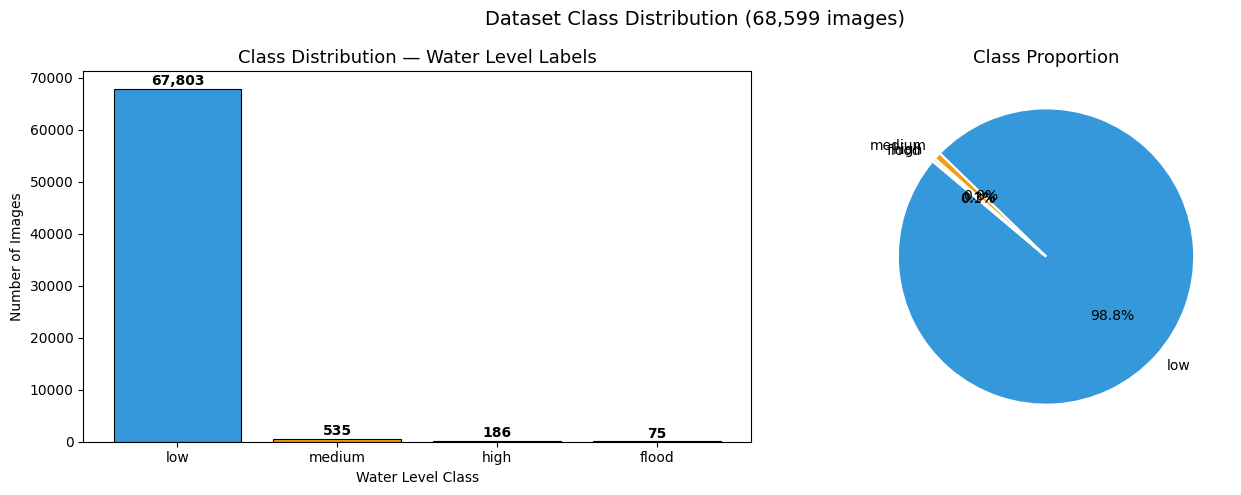


Class counts:
  low      → 67,803 images (98.8%)
  medium   →    535 images (0.8%)
  high     →    186 images (0.3%)
  flood    →     75 images (0.1%)


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("/kaggle/working/Images", exist_ok=True)

class_counts = df['level'].value_counts()
CLASS_ORDER  = ['low', 'medium', 'high', 'flood']   # logical water level order
class_counts = class_counts.reindex(CLASS_ORDER)

colors = ['#3498db', '#f39c12', '#e67e22', '#e74c3c']   # blue→orange→darkorange→red

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values, 
                   color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title("Class Distribution — Water Level Labels", fontsize=13)
axes[0].set_xlabel("Water Level Class")
axes[0].set_ylabel("Number of Images")
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{count:,}", ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Class Proportion", fontsize=13)

plt.suptitle("Dataset Class Distribution (68,599 images)", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/Images/class_distribution.png", dpi=150)
plt.show()

print("\nClass counts:")
for cls, cnt in class_counts.items():
    pct = cnt / len(df) * 100
    print(f"  {cls:8s} → {cnt:6,} images ({pct:.1f}%)")

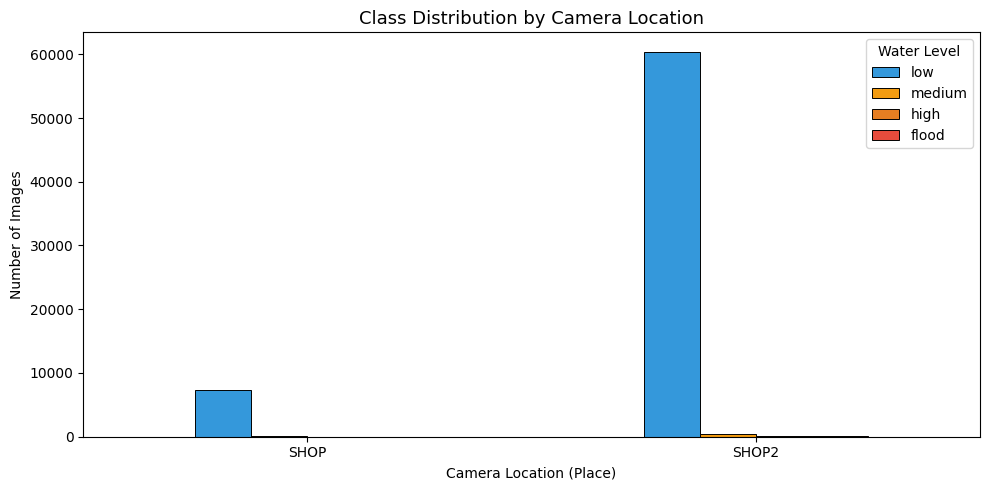

level    low  medium  high  flood
place                            
SHOP    7384      36    12      2
SHOP2  60419     499   174     73


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

place_level = df.groupby(['place', 'level']).size().unstack(fill_value=0)
place_level = place_level.reindex(columns=CLASS_ORDER)
place_level.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.7)

ax.set_title("Class Distribution by Camera Location", fontsize=13)
ax.set_xlabel("Camera Location (Place)")
ax.set_ylabel("Number of Images")
ax.legend(title="Water Level", loc='upper right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/Images/class_by_place.png", dpi=150)
plt.show()
print(place_level)

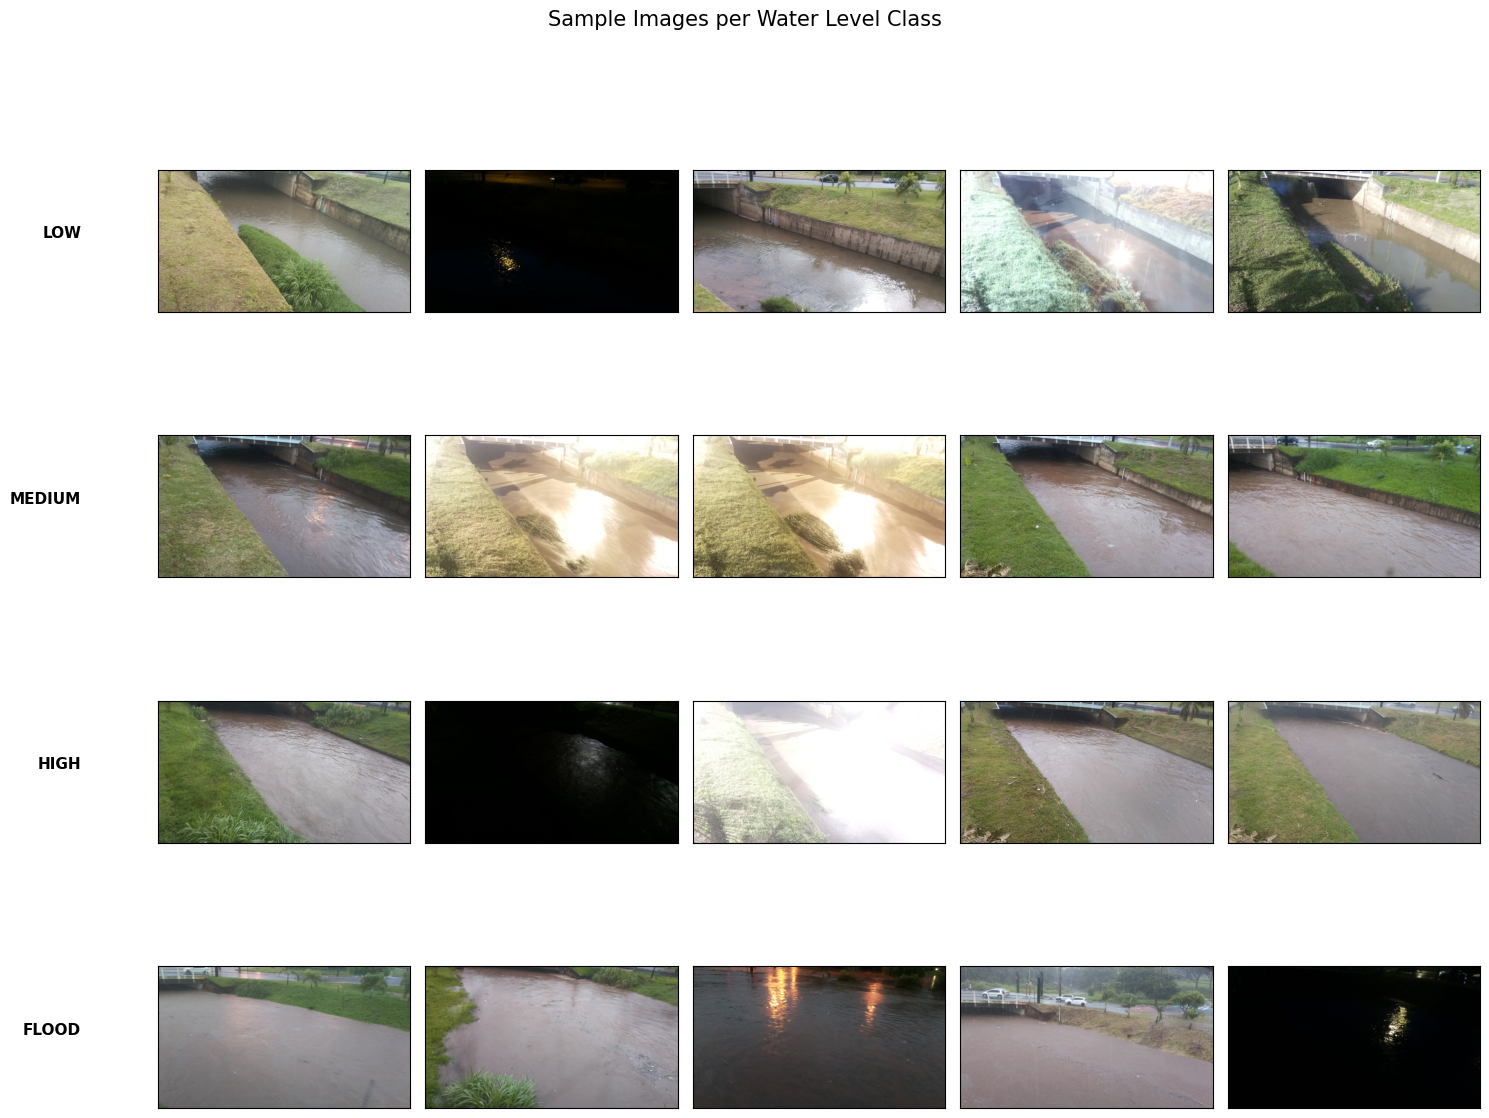

In [23]:
SAMPLES = 5
fig, axes = plt.subplots(len(CLASS_ORDER), SAMPLES, figsize=(SAMPLES * 3, len(CLASS_ORDER) * 3))

from PIL import Image

for row_idx, cls in enumerate(CLASS_ORDER):
    cls_df    = df[df['level'] == cls].sample(SAMPLES, random_state=42)
    for col_idx, (_, row) in enumerate(cls_df.iterrows()):
        ax = axes[row_idx][col_idx]
        try:
            img = Image.open(row['full_path']).convert('RGB')
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])
        if col_idx == 0:
            ax.set_ylabel(cls.upper(), fontsize=11, fontweight='bold',
                          rotation=0, ha='right', labelpad=55)

plt.suptitle("Sample Images per Water Level Class", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/Images/sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

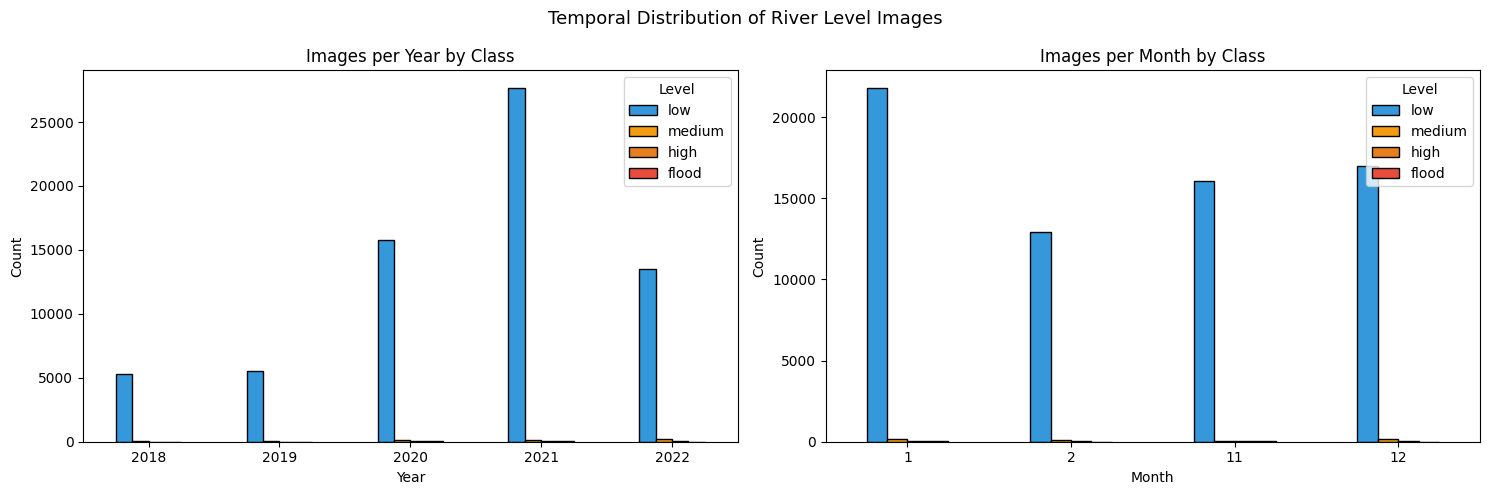

In [24]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['year']     = df['datetime'].dt.year
df['month']    = df['datetime'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Images per year
year_counts = df.groupby('year')['level'].value_counts().unstack(fill_value=0)
year_counts = year_counts.reindex(columns=CLASS_ORDER)
year_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title("Images per Year by Class", fontsize=12)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title="Level")

# Images per month (across all years)
month_counts = df.groupby('month')['level'].value_counts().unstack(fill_value=0)
month_counts = month_counts.reindex(columns=CLASS_ORDER)
month_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title("Images per Month by Class", fontsize=12)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title="Level")

plt.suptitle("Temporal Distribution of River Level Images", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/Images/temporal_distribution.png", dpi=150)
plt.show()

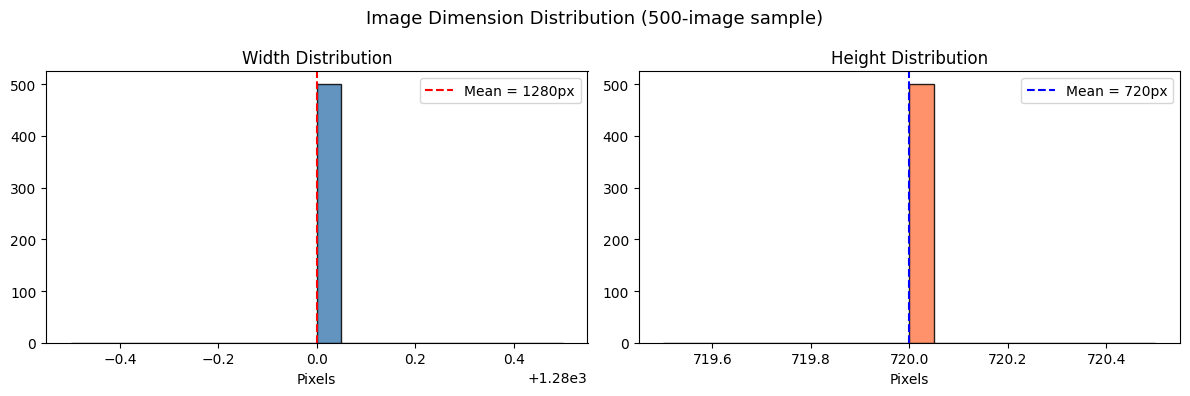

Width  → Min:1280  Max:1280  Mean:1280
Height → Min:720 Max:720 Mean:720


In [25]:
import numpy as np

widths, heights = [], []
SAMPLE_SIZE = 500   

sample_df = df.sample(SAMPLE_SIZE, random_state=42)
for _, row in sample_df.iterrows():
    try:
        img = Image.open(row['full_path'])
        w, h = img.size
        widths.append(w)
        heights.append(h)
    except:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].axvline(np.mean(widths), color='red', linestyle='--',
                label=f'Mean = {np.mean(widths):.0f}px')
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Pixels")
axes[0].legend()

axes[1].hist(heights, bins=20, color='coral', edgecolor='black', alpha=0.85)
axes[1].axvline(np.mean(heights), color='blue', linestyle='--',
                label=f'Mean = {np.mean(heights):.0f}px')
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Pixels")
axes[1].legend()

plt.suptitle("Image Dimension Distribution (500-image sample)", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/Images/image_size_distribution.png", dpi=150)
plt.show()
print(f"Width  → Min:{min(widths)}  Max:{max(widths)}  Mean:{np.mean(widths):.0f}")
print(f"Height → Min:{min(heights)} Max:{max(heights)} Mean:{np.mean(heights):.0f}")

In [26]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

CLASS_ORDER = ['low', 'medium', 'high', 'flood']
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42

# ── Take ALL minority images ────────────────────────────────────────────────
df_flood  = df[df['level'] == 'flood']    # all 75
df_high   = df[df['level'] == 'high']     # all 186
df_medium = df[df['level'] == 'medium']   # all 535

df_low = df[df['level'] == 'low'].sample(n=500, random_state=SEED)

df_model = pd.concat([df_low, df_medium, df_high, df_flood], ignore_index=True)
df_model = df_model.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Balanced dataset distribution:")
print(df_model['level'].value_counts())
print(f"Total: {len(df_model)} images")

# ── Train / Val split ───────────────────────────────────────────────────────
df_train, df_val = train_test_split(
    df_model, test_size=0.2,
    stratify=df_model['level'],
    random_state=SEED
)
print(f"\nTrain: {len(df_train)}  |  Val: {len(df_val)}")
print("\nTrain class counts:")
print(df_train['level'].value_counts())

# ── Label encoding ──────────────────────────────────────────────────────────
label_to_int = {cls: i for i, cls in enumerate(CLASS_ORDER)}
NUM_CLASSES  = len(CLASS_ORDER)

train_paths  = df_train['full_path'].values
train_labels = np.array([label_to_int[l] for l in df_train['level'].values])
val_paths    = df_val['full_path'].values
val_labels   = np.array([label_to_int[l] for l in df_val['level'].values])

print(f"\nLabel mapping: {label_to_int}")
print("✅ Balanced data split ready")

Balanced dataset distribution:
level
medium    535
low       500
high      186
flood      75
Name: count, dtype: int64
Total: 1296 images

Train: 1036  |  Val: 260

Train class counts:
level
medium    427
low       400
high      149
flood      60
Name: count, dtype: int64

Label mapping: {'low': 0, 'medium': 1, 'high': 2, 'flood': 3}
✅ Balanced data split ready


In [27]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_int = dict(enumerate(weights))
print("Class weights:", class_weight_int)

Class weights: {0: np.float64(0.6475), 1: np.float64(0.6065573770491803), 2: np.float64(1.738255033557047), 3: np.float64(4.316666666666666)}


In [28]:
def make_tf_dataset(paths, labels, augment=False):
    
    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32) / 255.0
        label = tf.one_hot(label, NUM_CLASSES)
        return img, label

    def augment_image(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
        img = tf.clip_by_value(img, 0.0, 1.0)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if augment:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_image,    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()            # ← cache images in memory after first epoch
    
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)  # ← GPU never waits for data
    return ds

train_ds = make_tf_dataset(train_paths, train_labels, augment=True)
val_ds   = make_tf_dataset(val_paths,   val_labels,   augment=False)

print(f"Train batches: {len(list(train_ds))}")
print(f"Val batches  : {len(list(val_ds))}")
print("✅ tf.data pipeline ready")

Train batches: 33
Val batches  : 9
✅ tf.data pipeline ready


In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

os.makedirs("/kaggle/working/Images", exist_ok=True)

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=6,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f"/kaggle/working/{model_name}_best.keras",
                        monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]
print("✅ Callbacks ready")

✅ Callbacks ready


In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import (VGG16, ResNet50, MobileNetV2,
                                            EfficientNetB0, DenseNet121)

NUM_CLASSES = 4

# ── MODEL 1: Custom CNN ─────────────────────────────────────────────────────
cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Custom_CNN")

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── MODEL 2: VGG16 ──────────────────────────────────────────────────────────
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False

vgg_model = models.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="VGG16")

vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── MODEL 3: ResNet50 ───────────────────────────────────────────────────────
res_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
res_base.trainable = False

inp = keras.Input(shape=(224, 224, 3))
x   = res_base(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(512, activation='relu')(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.5)(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
resnet_model = keras.Model(inp, out, name="ResNet50")

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── MODEL 4: MobileNetV2 ────────────────────────────────────────────────────
mob_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mob_base.trainable = False

inp = keras.Input(shape=(224, 224, 3))
x   = mob_base(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
mobilenet_model = keras.Model(inp, out, name="MobileNetV2")

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── MODEL 5: EfficientNetB0 ─────────────────────────────────────────────────
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
eff_base.trainable = False

inp = keras.Input(shape=(224, 224, 3))
x   = eff_base(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
efficientnet_model = keras.Model(inp, out, name="EfficientNetB0")

efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── MODEL 6: DenseNet121 ────────────────────────────────────────────────────
den_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
den_base.trainable = False

inp = keras.Input(shape=(224, 224, 3))
x   = den_base(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
densenet_model = keras.Model(inp, out, name="DenseNet121")

densenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Verify all 6 ────────────────────────────────────────────────────────────
all_models = {
    "Custom_CNN":     cnn_model,
    "VGG16":          vgg_model,
    "ResNet50":       resnet_model,
    "MobileNetV2":    mobilenet_model,
    "EfficientNetB0": efficientnet_model,
    "DenseNet121":    densenet_model,
}

print("✅ All 6 models ready:\n")
for name, model in all_models.items():
    trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"  {name:20s} → trainable params: {trainable:>10,}")

✅ All 6 models ready:

  Custom_CNN           → trainable params:    848,100
  VGG16                → trainable params:    396,036
  ResNet50             → trainable params:  1,182,468
  MobileNetV2          → trainable params:    329,476
  EfficientNetB0       → trainable params:    329,476
  DenseNet121          → trainable params:    263,940


In [31]:
import pickle

histories    = {}
all_val_acc  = {}

# All models use same train_ds / val_ds — no separate generators
training_configs = [
    (cnn_model,          "Custom_CNN"),
    (vgg_model,          "VGG16"),
    (resnet_model,       "ResNet50"),
    (mobilenet_model,    "MobileNetV2"),
    (efficientnet_model, "EfficientNetB0"),
    (densenet_model,     "DenseNet121"),
]

for model, name in training_configs:
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    history = model.fit(
        train_ds,
        epochs=30,
        validation_data=val_ds,
        class_weight=class_weight_int,
        callbacks=get_callbacks(name),
        verbose=1
    )
    histories[name] = history

    loss, acc = model.evaluate(val_ds, verbose=0)
    all_val_acc[name] = acc
    print(f"\n✅ {name} → Accuracy: {acc*100:.2f}%  Loss: {loss:.4f}")

    # Save after every model
    model.save(f'/kaggle/working/{name}_final.keras')
    with open('/kaggle/working/histories.pkl', 'wb') as f:
        pickle.dump(histories, f)
    print(f"💾 {name} saved.")


  Training: Custom_CNN
Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 254s 7s/step - accuracy: 0.3117 - loss: 2.0048 - val_accuracy: 0.0577 - val_loss: 1.7395 - learning_rate: 0.0010
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 253s 8s/step - accuracy: 0.3956 - loss: 1.5870 - val_accuracy: 0.0654 - val_loss: 1.6588 - learning_rate: 0.0010
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 247s 7s/step - accuracy: 0.4345 - loss: 1.4671 - val_accuracy: 0.3577 - val_loss: 1.4766 - learning_rate: 0.0010
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 258s 8s/step - accuracy: 0.4892 - loss: 1.3641 - val_accuracy: 0.0577 - val_loss: 2.1587 - learning_rate: 0.0010
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 246s 7s/step - accuracy: 0.4592 - loss: 1.4221 - val_accuracy: 0.3808 - val_loss: 1.6998 - learning_rate: 0.0010
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4523 - loss: 1.4895
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
33/33 ━━━━━━━━━━━━━━━━━━━━ 252s 8s/step - accuracy: 0.4522 - l

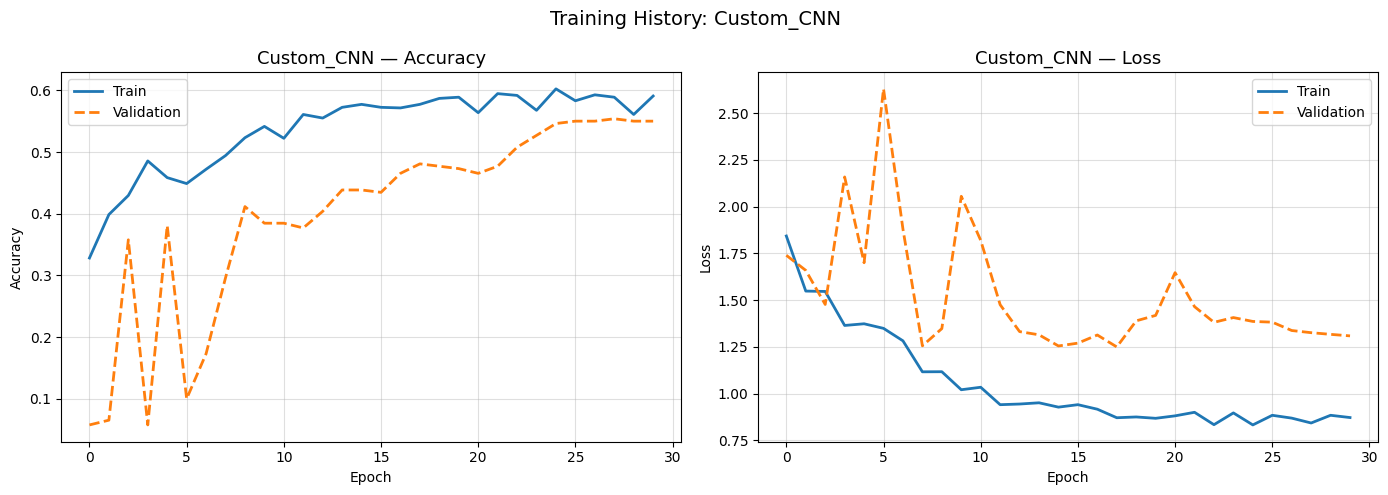

✅ Saved curves_custom_cnn.png


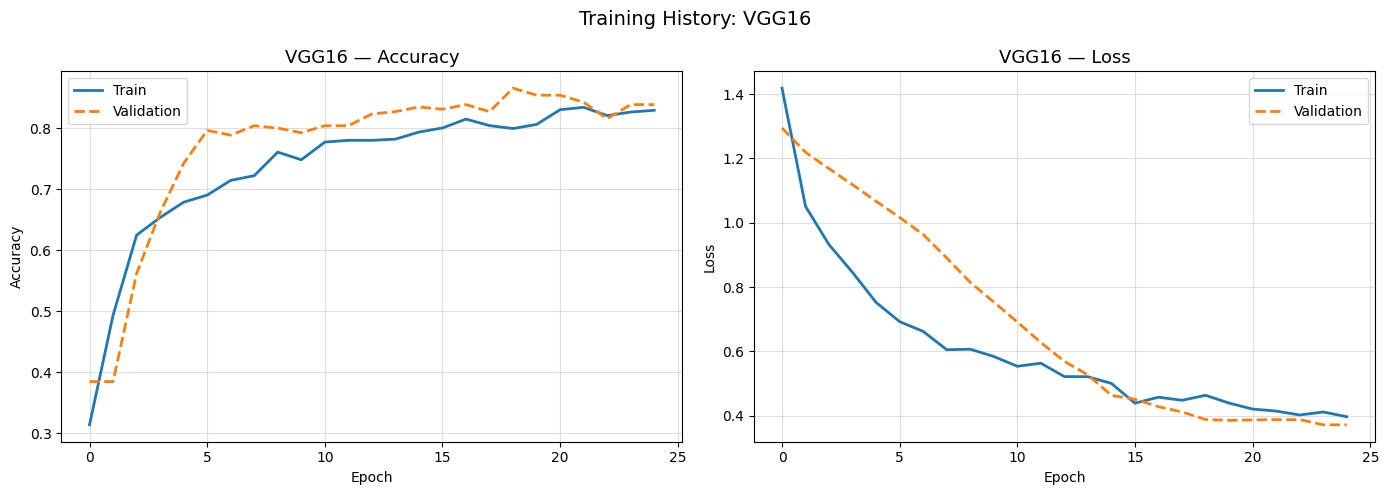

✅ Saved curves_vgg16.png


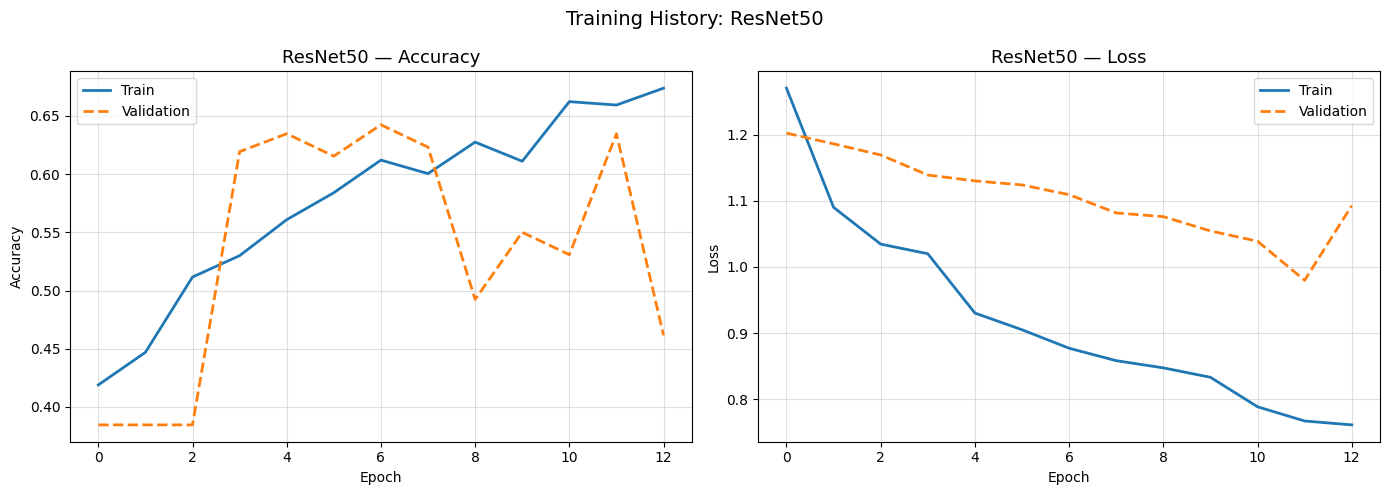

✅ Saved curves_resnet50.png


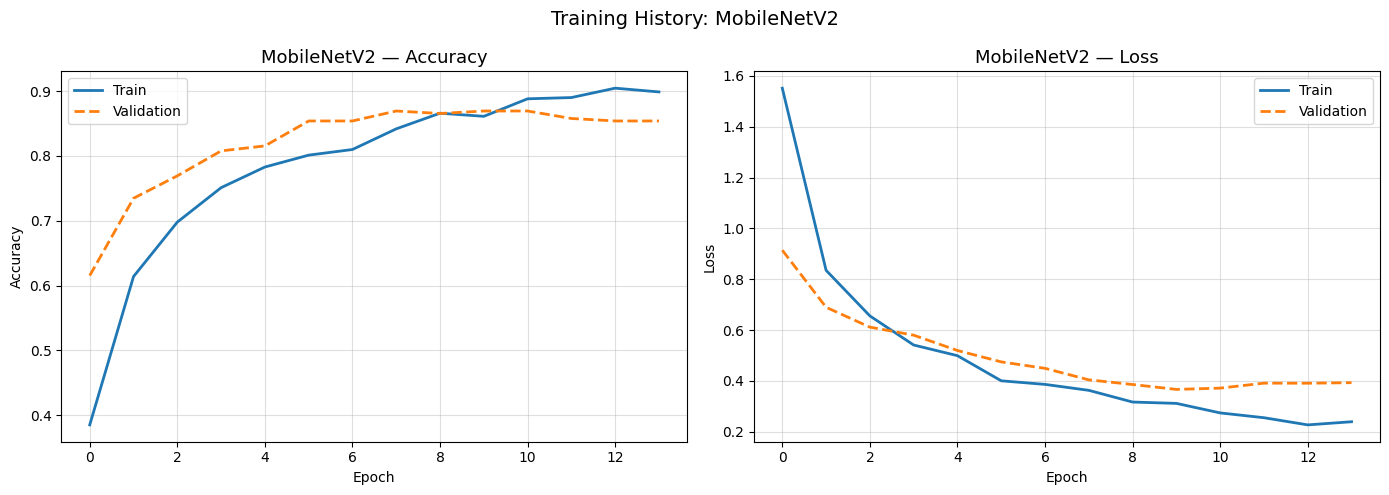

✅ Saved curves_mobilenetv2.png


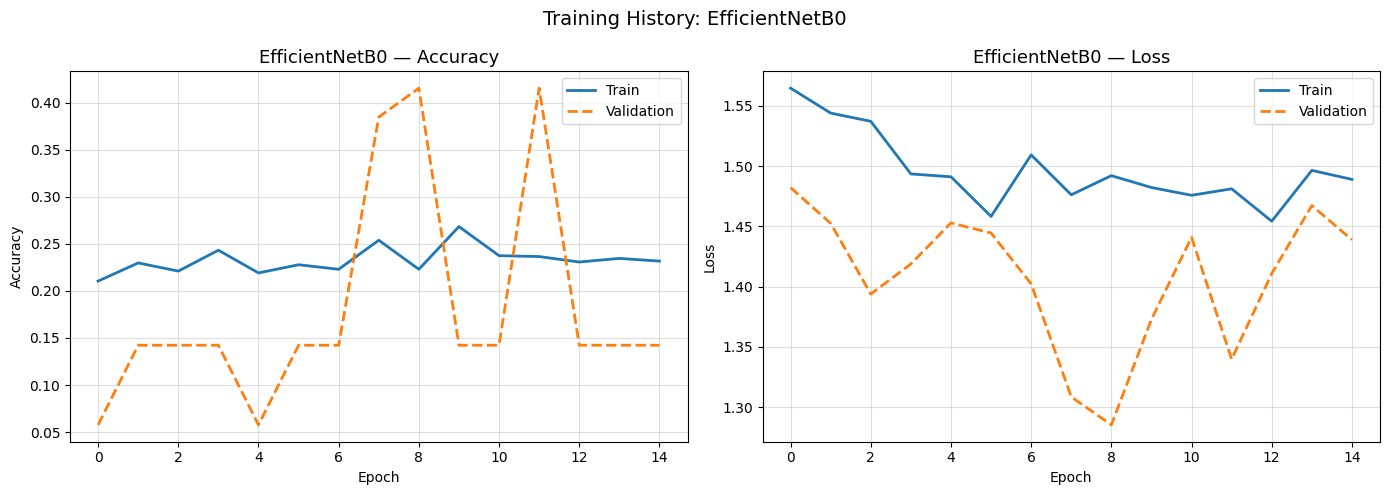

✅ Saved curves_efficientnetb0.png


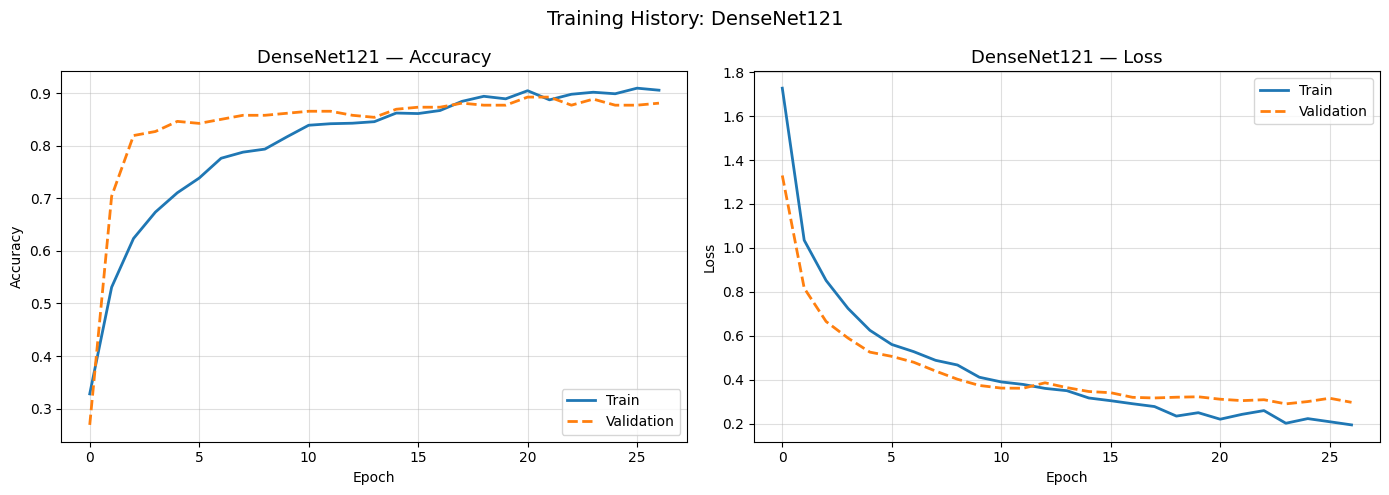

✅ Saved curves_densenet121.png


In [32]:
def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', 
                 linewidth=2, linestyle='--')
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)

    axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', 
                 linewidth=2, linestyle='--')
    axes[1].set_title(f'{model_name} — Loss', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.suptitle(f'Training History: {model_name}', fontsize=14)
    plt.tight_layout()
    safe = model_name.lower().replace(' ', '_')
    plt.savefig(f"/kaggle/working/Images/curves_{safe}.png", dpi=150)
    plt.show()
    print(f"✅ Saved curves_{safe}.png")

for name, hist in histories.items():
    plot_training_curves(hist, name)


──────────────────────────────────────────────────
 Evaluating: Custom_CNN
──────────────────────────────────────────────────
  Accuracy  : 55.38%
  Precision : 48.96%
  Recall    : 52.99%
  F1-Score  : 46.94%

Classification Report:
              precision    recall  f1-score   support

         low       0.82      0.76      0.79       100
      medium       0.68      0.44      0.53       108
        high       0.31      0.32      0.32        37
       flood       0.15      0.60      0.24        15

    accuracy                           0.55       260
   macro avg       0.49      0.53      0.47       260
weighted avg       0.65      0.55      0.58       260



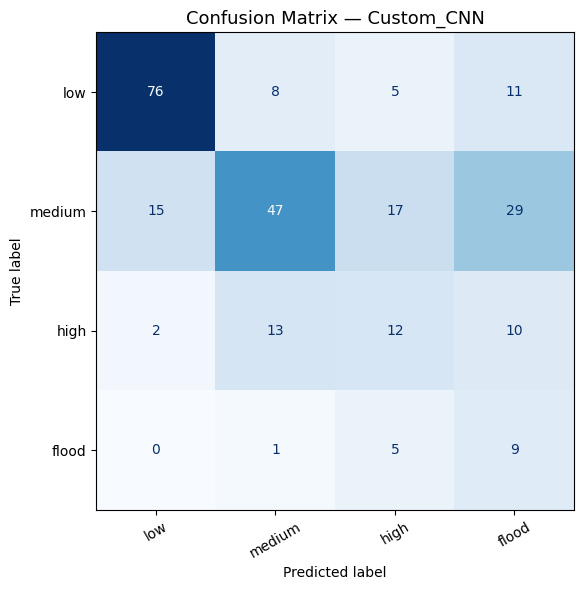

✅ Saved confusion_matrix_custom_cnn.png

──────────────────────────────────────────────────
 Evaluating: VGG16
──────────────────────────────────────────────────
  Accuracy  : 86.54%
  Precision : 81.03%
  Recall    : 83.63%
  F1-Score  : 81.90%

Classification Report:
              precision    recall  f1-score   support

         low       1.00      0.91      0.95       100
      medium       0.84      0.91      0.87       108
        high       0.67      0.59      0.63        37
       flood       0.74      0.93      0.82        15

    accuracy                           0.87       260
   macro avg       0.81      0.84      0.82       260
weighted avg       0.87      0.87      0.87       260



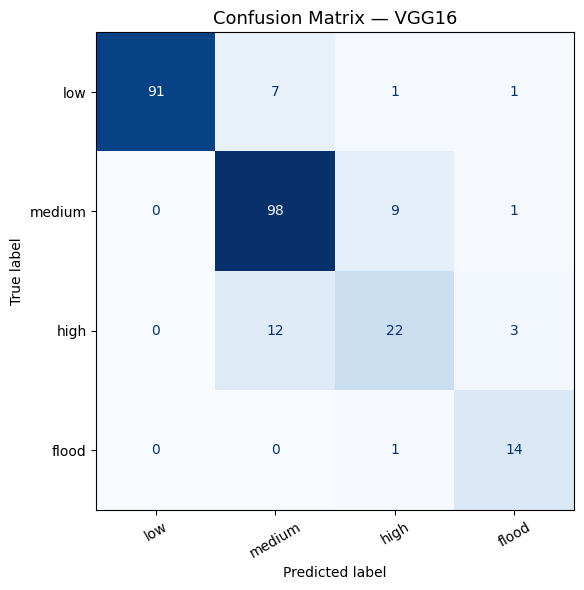

✅ Saved confusion_matrix_vgg16.png

──────────────────────────────────────────────────
 Evaluating: ResNet50
──────────────────────────────────────────────────
  Accuracy  : 64.23%
  Precision : 34.83%
  Recall    : 39.90%
  F1-Score  : 35.97%

Classification Report:
              precision    recall  f1-score   support

         low       0.84      0.67      0.74       100
      medium       0.56      0.93      0.69       108
        high       0.00      0.00      0.00        37
       flood       0.00      0.00      0.00        15

    accuracy                           0.64       260
   macro avg       0.35      0.40      0.36       260
weighted avg       0.55      0.64      0.57       260



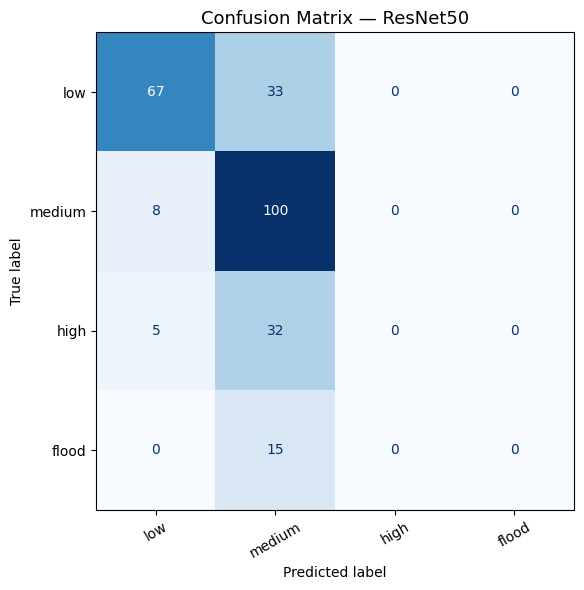

✅ Saved confusion_matrix_resnet50.png

──────────────────────────────────────────────────
 Evaluating: MobileNetV2
──────────────────────────────────────────────────
  Accuracy  : 86.92%
  Precision : 81.45%
  Recall    : 82.93%
  F1-Score  : 82.08%

Classification Report:
              precision    recall  f1-score   support

         low       0.98      0.94      0.96       100
      medium       0.86      0.89      0.87       108
        high       0.66      0.62      0.64        37
       flood       0.76      0.87      0.81        15

    accuracy                           0.87       260
   macro avg       0.81      0.83      0.82       260
weighted avg       0.87      0.87      0.87       260



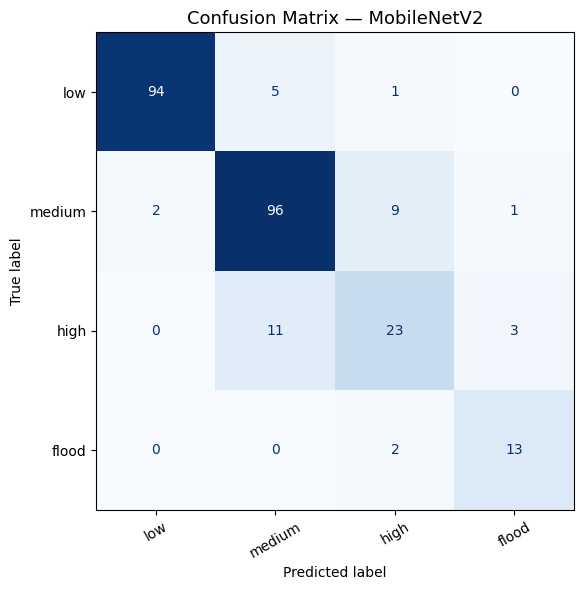

✅ Saved confusion_matrix_mobilenetv2.png

──────────────────────────────────────────────────
 Evaluating: EfficientNetB0
──────────────────────────────────────────────────
  Accuracy  : 41.54%
  Precision : 10.38%
  Recall    : 25.00%
  F1-Score  : 14.67%

Classification Report:
              precision    recall  f1-score   support

         low       0.00      0.00      0.00       100
      medium       0.42      1.00      0.59       108
        high       0.00      0.00      0.00        37
       flood       0.00      0.00      0.00        15

    accuracy                           0.42       260
   macro avg       0.10      0.25      0.15       260
weighted avg       0.17      0.42      0.24       260



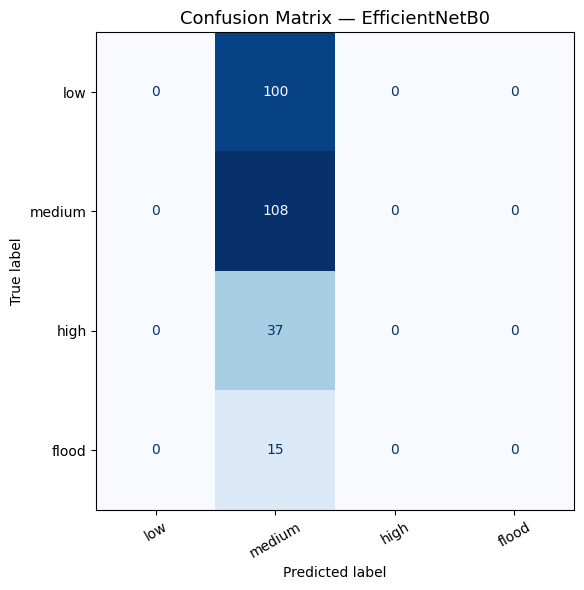

✅ Saved confusion_matrix_efficientnetb0.png

──────────────────────────────────────────────────
 Evaluating: DenseNet121
──────────────────────────────────────────────────
  Accuracy  : 89.23%
  Precision : 84.55%
  Recall    : 87.59%
  F1-Score  : 85.95%

Classification Report:
              precision    recall  f1-score   support

         low       0.98      0.97      0.97       100
      medium       0.90      0.87      0.89       108
        high       0.68      0.73      0.70        37
       flood       0.82      0.93      0.88        15

    accuracy                           0.89       260
   macro avg       0.85      0.88      0.86       260
weighted avg       0.90      0.89      0.89       260



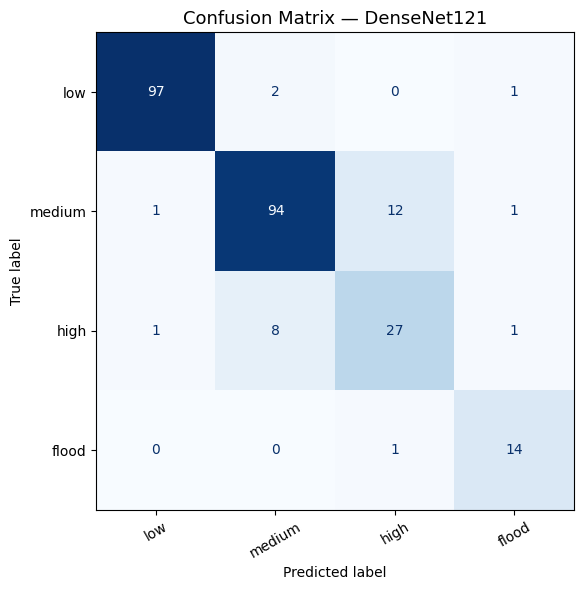

✅ Saved confusion_matrix_densenet121.png


In [33]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score,
                             precision_score, recall_score)

all_models = {
    "Custom_CNN":     cnn_model,
    "VGG16":          vgg_model,
    "ResNet50":       resnet_model,
    "MobileNetV2":    mobilenet_model,
    "EfficientNetB0": efficientnet_model,
    "DenseNet121":    densenet_model,
}

all_results = {}

for name, model in all_models.items():
    print(f"\n{'─'*50}")
    print(f" Evaluating: {name}")
    print(f"{'─'*50}")

    # Get predictions
    y_pred_probs = model.predict(val_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Get true labels from val_ds
    y_true = np.concatenate([
        np.argmax(y.numpy(), axis=1) for _, y in val_ds
    ])

    loss, acc = model.evaluate(val_ds, verbose=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score   (y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score       (y_true, y_pred, average='macro', zero_division=0)

    all_results[name] = {
        "accuracy":  acc,
        "loss":      loss,
        "precision": prec,
        "recall":    rec,
        "f1":        f1
    }

    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print(f"  F1-Score  : {f1*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, 
                                target_names=CLASS_ORDER, zero_division=0))

    # Confusion Matrix
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=30, colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=13)
    plt.tight_layout()
    safe = name.lower().replace(' ', '_')
    plt.savefig(f"/kaggle/working/Images/confusion_matrix_{safe}.png", dpi=150)
    plt.show()
    print(f"✅ Saved confusion_matrix_{safe}.png")

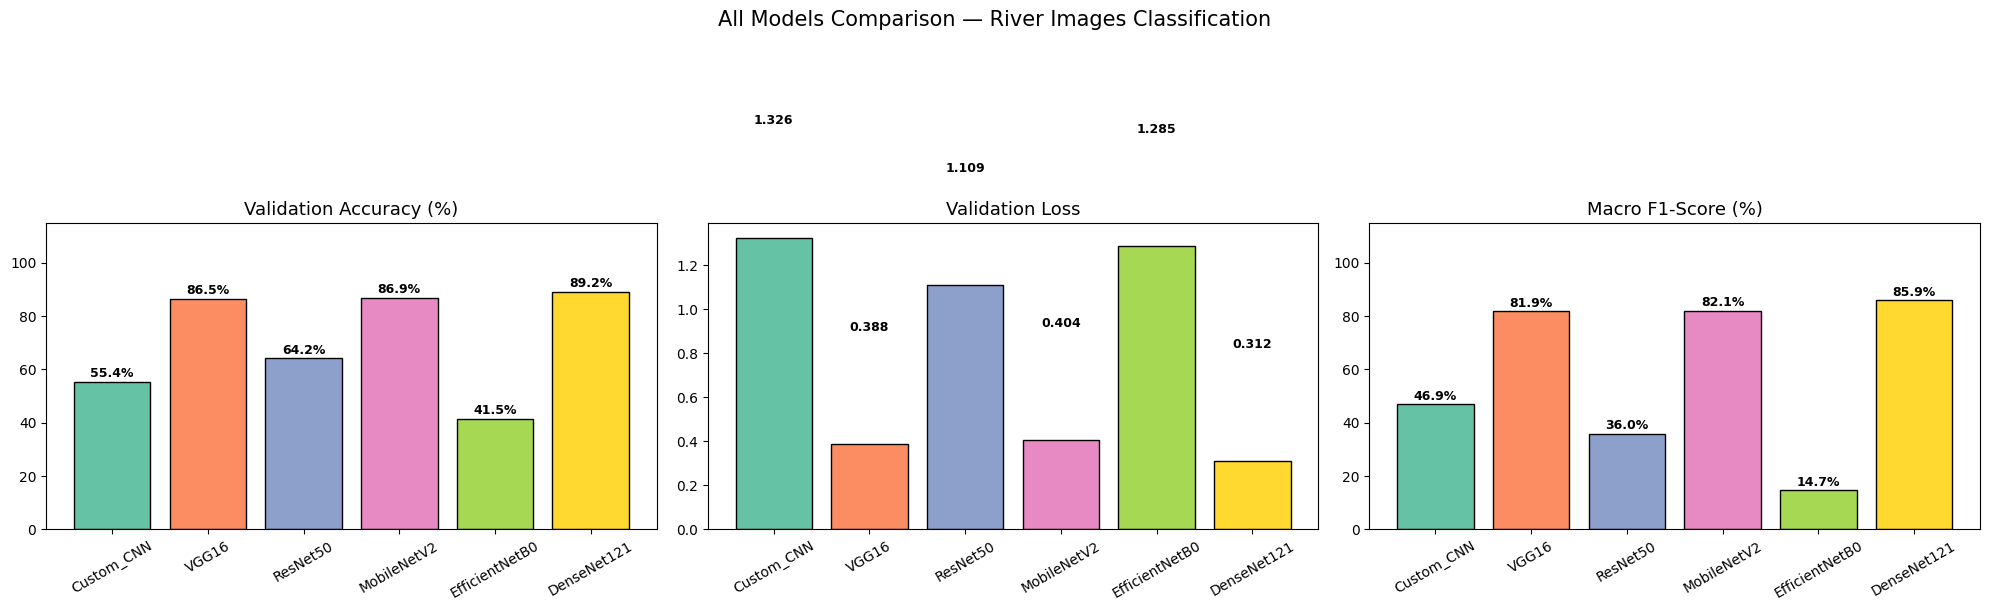

✅ Saved accuracy_comparison.png


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

names     = list(all_results.keys())
accs      = [all_results[m]['accuracy']  * 100 for m in names]
losses    = [all_results[m]['loss']            for m in names]
f1_scores = [all_results[m]['f1']        * 100 for m in names]
palette   = sns.color_palette("Set2", len(names))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

def add_labels(ax, bars, fmt):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                fmt.format(h), ha='center', va='bottom',
                fontsize=9, fontweight='bold')

b1 = axes[0].bar(names, accs, color=palette, edgecolor='black')
axes[0].set_title("Validation Accuracy (%)", fontsize=13)
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis='x', rotation=30)
add_labels(axes[0], b1, "{:.1f}%")

b2 = axes[1].bar(names, losses, color=palette, edgecolor='black')
axes[1].set_title("Validation Loss", fontsize=13)
axes[1].tick_params(axis='x', rotation=30)
add_labels(axes[1], b2, "{:.3f}")

b3 = axes[2].bar(names, f1_scores, color=palette, edgecolor='black')
axes[2].set_title("Macro F1-Score (%)", fontsize=13)
axes[2].set_ylim(0, 115)
axes[2].tick_params(axis='x', rotation=30)
add_labels(axes[2], b3, "{:.1f}%")

plt.suptitle("All Models Comparison — River Images Classification",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/Images/accuracy_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved accuracy_comparison.png")

In [35]:
import pandas as pd

summary_df = pd.DataFrame([{
    "Model":            name,
    "Val Accuracy (%)": round(all_results[name]['accuracy']  * 100, 2),
    "Val Loss":         round(all_results[name]['loss'],            4),
    "Precision (%)":    round(all_results[name]['precision'] * 100, 2),
    "Recall (%)":       round(all_results[name]['recall']    * 100, 2),
    "F1-Score (%)":     round(all_results[name]['f1']        * 100, 2),
} for name in all_results]).sort_values(
    "Val Accuracy (%)", ascending=False
).reset_index(drop=True)

print("\n🏆 FINAL MODEL COMPARISON\n")
print(summary_df.to_string(index=False))

best = summary_df.iloc[0]
print(f"\n✅ Best Model : {best['Model']}")
print(f"   Accuracy   : {best['Val Accuracy (%)']:.2f}%")
print(f"   F1-Score   : {best['F1-Score (%)']:.2f}%")


🏆 FINAL MODEL COMPARISON

         Model  Val Accuracy (%)  Val Loss  Precision (%)  Recall (%)  F1-Score (%)
   DenseNet121             89.23    0.3121          84.55       87.59         85.95
   MobileNetV2             86.92    0.4043          81.45       82.93         82.08
         VGG16             86.54    0.3878          81.03       83.63         81.90
      ResNet50             64.23    1.1094          34.83       39.90         35.97
    Custom_CNN             55.38    1.3255          48.96       52.99         46.94
EfficientNetB0             41.54    1.2854          10.38       25.00         14.67

✅ Best Model : DenseNet121
   Accuracy   : 89.23%
   F1-Score   : 85.95%


In [36]:
files = sorted(os.listdir("/kaggle/working/Images/"))
print(f"Total images saved: {len(files)}\n")
for f in files:
    print(f"  ✅ {f}")

Total images saved: 18

  ✅ accuracy_comparison.png
  ✅ class_by_place.png
  ✅ class_distribution.png
  ✅ confusion_matrix_custom_cnn.png
  ✅ confusion_matrix_densenet121.png
  ✅ confusion_matrix_efficientnetb0.png
  ✅ confusion_matrix_mobilenetv2.png
  ✅ confusion_matrix_resnet50.png
  ✅ confusion_matrix_vgg16.png
  ✅ curves_custom_cnn.png
  ✅ curves_densenet121.png
  ✅ curves_efficientnetb0.png
  ✅ curves_mobilenetv2.png
  ✅ curves_resnet50.png
  ✅ curves_vgg16.png
  ✅ image_size_distribution.png
  ✅ sample_images.png
  ✅ temporal_distribution.png


In [37]:
import pickle

with open('/kaggle/working/histories.pkl', 'wb') as f:
    pickle.dump(histories, f)

with open('/kaggle/working/all_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)

print("✅ All results saved.")
print("\nFiles in /kaggle/working/:")
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f"  {f}  ({size/1024:.1f} KB)")

✅ All results saved.

Files in /kaggle/working/:
  .virtual_documents  (4.0 KB)
  DenseNet121_final.keras  (32077.3 KB)
  DenseNet121_best.keras  (32077.3 KB)
  ResNet50_final.keras  (106662.2 KB)
  Custom_CNN_final.keras  (10059.1 KB)
  MobileNetV2_final.keras  (13268.7 KB)
  EfficientNetB0_final.keras  (20519.3 KB)
  Custom_CNN_best.keras  (10059.1 KB)
  MobileNetV2_best.keras  (13268.7 KB)
  VGG16_best.keras  (62227.7 KB)
  VGG16_final.keras  (62227.7 KB)
  Images  (4.0 KB)
  all_results.pkl  (0.5 KB)
  histories.pkl  (244821.2 KB)
  EfficientNetB0_best.keras  (20519.3 KB)
  ResNet50_best.keras  (106662.2 KB)
